# IT Support Ticket Classifier: TF-IDF + Logistic Regression Baseline

In [11]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

sns.set_style("whitegrid")


## 0. Paths


In [12]:
DATA_DIR = os.path.abspath('../data')
MODEL_DIR = os.path.abspath('../models/baseline')
RESULTS_DIR = os.path.abspath('../results')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Data:    {DATA_DIR}")
print(f"Model:   {MODEL_DIR}")
print(f"Results: {RESULTS_DIR}")


Data:    c:\Users\jysob\Desktop\aig-ticketclass\data
Model:   c:\Users\jysob\Desktop\aig-ticketclass\models\baseline
Results: c:\Users\jysob\Desktop\aig-ticketclass\results


## 1. Load the data splits (from 01)

In [13]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")
train_df.head()


Train: (350, 5) | Val: (75, 5) | Test: (75, 5)


,subject,description,full_text,category_final,priority
0,Cloud Identity Verification Issue,It seems like the enterprise cloud-based ident...,Cloud Identity Verification Issue. It seems li...,Software,High
1,Assistance Required for Diagnosing and Resolvi...,Name: Alex Johnson Email: alex.johnson@acme.co...,Assistance Required for Diagnosing and Resolvi...,Network,Medium
2,ZDesk Console Access Request,Hello! Jane Doe (jane.doe@acme.co) should be g...,ZDesk Console Access Request. Hello! Jane Doe ...,Account,Medium
3,Access Request for GH Team Projects,Hello IT! I need access to the GH Team Project...,Access Request for GH Team Projects. Hello IT!...,Account,Medium
4,Live Streaming Issues on Virtual Event Platform,"Hi IT Team, we're experiencing persistent issu...",Live Streaming Issues on Virtual Event Platfor...,Network,High


In [14]:
LABEL_COL = 'category_final'
TEXT_COL = 'full_text'

print("Train category distribution:")
print(train_df[LABEL_COL].value_counts())


Train category distribution:
category_final
Software         162
Account           50
Network           48
Security          29
Communication     17
Other             15
Hardware          15
RemoteWork        14
Name: count, dtype: int64


## 2. TF-IDF vectorization

Parameter choices:
- `ngram_range=(1, 2)`: captures short phrases ("won't", "can not connect"), not just
  single words, without exploding vocabulary size the way trigrams would
- `stop_words='english'`: removes low-signal words (the, is, a) that TF-IDF would
  otherwise waste weight on
- `min_df=2`: drops words appearing in only one ticket (likely noise or typos, not
  generalizable signal)
- `max_features=5000`: caps vocabulary size for speed; adjust up if EDA showed a much
  larger unique vocabulary


In [15]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
)

X_train = vectorizer.fit_transform(train_df[TEXT_COL])
X_val = vectorizer.transform(val_df[TEXT_COL])
X_test = vectorizer.transform(test_df[TEXT_COL])

y_train = train_df[LABEL_COL]
y_val = val_df[LABEL_COL]
y_test = test_df[LABEL_COL]

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")


Vocabulary size: 2547
X_train shape: (350, 2547)


## 3. Train Logistic Regression

Note: `class_weight='balanced'`: automatically re-weights the loss so rare categories aren't ignored.
- We try a few candidates and pick whichever scores best on the **validation** set
- Use **macro-averaged** F1 (not weighted or micro) to pick the winner


In [16]:
candidate_Cs = [0.1, 1.0, 5.0, 10.0]
best_c, best_f1, best_model = None, -1, None

for C in candidate_Cs:
    model = LogisticRegression(
        C=C,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
    )
    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    _, _, val_f1, _ = precision_recall_fscore_support(
        y_val, val_preds, average='macro', zero_division=0
    )
    print(f"C={C}: validation macro-F1 = {val_f1:.3f}")

    if val_f1 > best_f1:
        best_c, best_f1, best_model = C, val_f1, model

print(f"\nSelected C={best_c} (validation macro-F1={best_f1:.3f})")


C=0.1: validation macro-F1 = 0.632
C=1.0: validation macro-F1 = 0.657
C=5.0: validation macro-F1 = 0.588
C=10.0: validation macro-F1 = 0.579

Selected C=1.0 (validation macro-F1=0.657)


## 4. Final evaluation on test set


In [17]:
test_preds = best_model.predict(X_test)

acc = accuracy_score(y_test, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, test_preds, average='macro', zero_division=0
)

print(f"Test accuracy:              {acc:.3f}")
print(f"Test macro precision:       {precision:.3f}")
print(f"Test macro recall:          {recall:.3f}")
print(f"Test macro F1:              {f1:.3f}")

print("\nFull per-class report:")
print(classification_report(y_test, test_preds, zero_division=0))


Test accuracy:              0.720
Test macro precision:       0.655
Test macro recall:          0.743
Test macro F1:              0.680

Full per-class report:
               precision    recall  f1-score   support

      Account       0.50      0.80      0.62        10
Communication       0.50      1.00      0.67         4
     Hardware       0.75      1.00      0.86         3
      Network       0.90      0.90      0.90        10
        Other       0.00      0.00      0.00         4
   RemoteWork       1.00      1.00      1.00         3
     Security       0.80      0.57      0.67         7
     Software       0.79      0.68      0.73        34

     accuracy                           0.72        75
    macro avg       0.66      0.74      0.68        75
 weighted avg       0.72      0.72      0.71        75



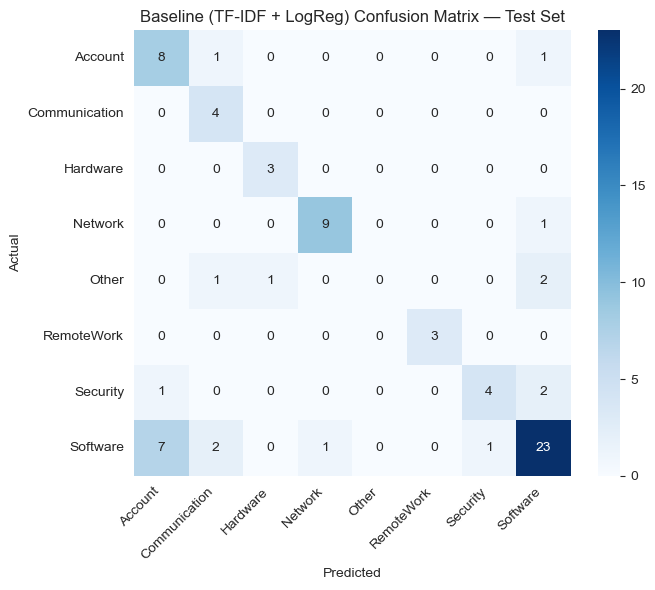

In [18]:
labels = sorted(y_train.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline (TF-IDF + LogReg) Confusion Matrix — Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/baseline_confusion_matrix.png", dpi=150)
plt.show()


## 5. Top predictive words per category


In [19]:
feature_names = np.array(vectorizer.get_feature_names_out())

print("Top 8 words/phrases for each category's predictions:\n")
for i, cls in enumerate(best_model.classes_):
    top_idx = np.argsort(best_model.coef_[i])[-8:][::-1]
    top_words = feature_names[top_idx].tolist()
    print(f"{cls}:")
    print(f"  {top_words}\n")


Top 8 words/phrases for each category's predictions:

Account:
  ['access', 'password', 'dbox', 'account', 'access request', 'request', 'gh', 'sf']

Communication:
  ['slack', 'mobile', 'channels', 'mobile device', 'zoom', 'device', 'email', 'email mobile']

Hardware:
  ['printer', 'monitor', 'office', 'office printer', 'hardware', 'display', 'token', 'dual']

Network:
  ['network', 'connection', 'network drive', 'drive', 'shared', 'shared network', 'internet', 'slow']

Other:
  ['help', 'google calendar', 'vdi', 'google', 'new google', 'calendar', 'training', 'sure']

RemoteWork:
  ['remote', 'remote desktop', 'desktop', 'desktop access', 'personal', 'smartphone', 'tablet', 'new smartphone']

Security:
  ['security', 'workstation', 'phishing email', 'phishing', 'multi factor', 'authentication', 'factor', 'factor authentication']

Software:
  ['data', 'tools', 'cloud', 'adobe', 'document', 'management', 'based', 'asana']



## 6. Save artifacts

- `baseline_results.json`: loaded to build the final side-by-side comparison table without needing to retrain or re-run this notebook


In [20]:
joblib.dump(vectorizer, f"{MODEL_DIR}/tfidf_vectorizer.joblib")
joblib.dump(best_model, f"{MODEL_DIR}/logreg_model.joblib")

baseline_results = {
    'model_name': 'TF-IDF + Logistic Regression',
    'best_C': best_c,
    'test_accuracy': float(acc),
    'test_macro_precision': float(precision),
    'test_macro_recall': float(recall),
    'test_macro_f1': float(f1),
    'test_predictions': test_preds.tolist(),
    'test_true_labels': y_test.tolist(),
    'class_labels': labels,
}

with open(f"{RESULTS_DIR}/baseline_results.json", 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("Saved:")
print(f"  {MODEL_DIR}/tfidf_vectorizer.joblib")
print(f"  {MODEL_DIR}/logreg_model.joblib")
print(f"  {RESULTS_DIR}/baseline_results.json")
print(f"  {RESULTS_DIR}/baseline_confusion_matrix.png")
print("\nCommit and push.")

Saved:
  c:\Users\jysob\Desktop\aig-ticketclass\models\baseline/tfidf_vectorizer.joblib
  c:\Users\jysob\Desktop\aig-ticketclass\models\baseline/logreg_model.joblib
  c:\Users\jysob\Desktop\aig-ticketclass\results/baseline_results.json
  c:\Users\jysob\Desktop\aig-ticketclass\results/baseline_confusion_matrix.png

Commit and push.


## Notes to carry into your write-up

- **Baseline test accuracy:** ___  |  **Macro F1:** ___
- **Chosen C:** ___ (from validation sweep — note which candidates were tried and why this one won)
- **Most informative words per category:** pick 2-3 categories where the top words make
  intuitive sense (or surprisingly don't) — good error-analysis-adjacent material
- **What this baseline can't do:** it only sees word overlap — two categories that share
  vocabulary but differ in meaning (e.g. "can't connect" appearing in both Network and
  Account tickets) are where you'd expect it to struggle. Keep this in mind for Notebook
  3's comparison discussion.
